Text(0.5, 1.0, 'Simulated spikes')

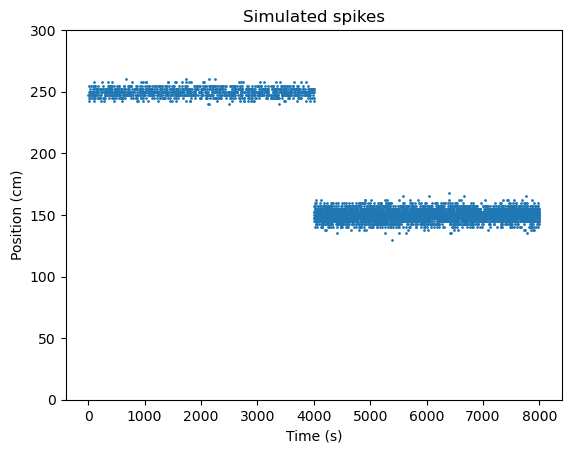

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def log_receptive_field_model(position: np.ndarray, params: np.ndarray) -> np.ndarray:
    log_max_rate, place_field_center, scale = params
    return log_max_rate - (position - place_field_center) ** 2 / (2 * scale**2)


def receptive_field_model(position: np.ndarray, params: np.ndarray) -> np.ndarray:
    return np.exp(log_receptive_field_model(position, params))


def simulate_eden_brown_2004_jump():
    dt = 0.020  # seconds
    total_time = 8000.0  # seconds
    n_total_steps = int(total_time / dt)

    time = np.arange(0, total_time, dt)

    speed = 125.0  # cm/s
    track_length = 300.0  # cm

    run1 = np.arange(0, track_length, speed * dt)
    run2 = np.arange(track_length, 0, -speed * dt)
    run = np.concatenate((run1, run2))

    position = np.concatenate([run] * int(np.ceil(n_total_steps / run.shape[0])))
    position = position[:n_total_steps]

    true_params1 = np.array([np.log(10.0), 250.0, np.sqrt(12.0)])
    true_params2 = np.array([np.log(30.0), 150.0, np.sqrt(20.0)])
    true_rate1 = receptive_field_model(position[: position.shape[0] // 2], true_params1)
    true_rate2 = receptive_field_model(position[position.shape[0] // 2 :], true_params2)
    true_rate = np.concatenate((true_rate1, true_rate2))
    spike_indicator = np.random.poisson(true_rate * dt)

    return time, position, spike_indicator, dt, true_params1, true_params2

time, position, spike_indicator, dt, true_params1, true_params2 = simulate_eden_brown_2004_jump()

plt.scatter(
    time[spike_indicator.nonzero()[0]], position[spike_indicator.nonzero()[0]], s=1
)
plt.ylim((0, 300))
plt.ylabel("Position (cm)")
plt.xlabel("Time (s)")
plt.title("Simulated spikes")

In [2]:
import jax
import jax.numpy as jnp


def log_receptive_field_model(
    position: jnp.ndarray, params: jnp.ndarray
) -> jnp.ndarray:
    log_max_rate, place_field_center, scale = params
    return log_max_rate - (position - place_field_center) ** 2 / (2 * scale**2)


def receptive_field_model(position: jnp.ndarray, params: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(log_receptive_field_model(position, params))


def stochastic_point_process_filter(
    init_mean_params: jnp.ndarray,
    init_variance_params: jnp.ndarray,
    x: jnp.ndarray,
    spike_indicator: jnp.ndarray,
    dt: float,
    transition_matrix: jnp.ndarray,
    covariance_matrix: jnp.ndarray,
    log_receptive_field_model: callable,
) -> tuple[jnp.ndarray, jnp.ndarray]:
    """Stochastic State Point Process Filter (SSPPF)

    Parameters
    ----------
    init_mean_params : jnp.ndarray, shape (n_params,)
        Initial mean parameters
    init_variance_params : jnp.ndarray, shape (n_params, n_params)
        Initial variance parameters
    x : jnp.ndarray, shape (n_time,)
        linear-valued input signal
    spike_indicator : jnp.ndarray, shape (n_time,)
        Spike count
    dt : float
        Time step
    transition_matrix : jnp.ndarray, shape (n_params, n_params)
    covariance_matrix : jnp.ndarray, shape (n_params, n_params)
    log_receptive_field_model : callable
        Function that takes in `x` and parameters and returns the log spike rate

    Returns
    -------
    posterior_mode : jnp.ndarray, shape (n_time, n_params)
    posterior_variance : jnp.ndarray, shape (n_time, n_params, n_params)

    References
    ----------
    ...[1] Eden, U. T., Frank, L. M., Barbieri, R., Solo, V. & Brown, E. N.
      Dynamic Analysis of Neural Encoding by Point Process Adaptive Filtering.
      Neural Computation 16, 971-998 (2004).


    """

    grad_log_receptive_field_model = jax.grad(
        log_receptive_field_model, argnums=1
    )  # repalce with jax.jacobian or jax.jacfwd?
    hess_log_receptive_field_model = jax.hessian(log_receptive_field_model, argnums=1)

    def _update(
        params_prev: tuple[jnp.ndarray, jnp.ndarray],
        args: tuple[jnp.ndarray, jnp.ndarray],
    ) -> tuple[tuple[jnp.ndarray, jnp.ndarray], tuple[jnp.ndarray, jnp.ndarray]]:
        """Point Process Adaptive Filter update step

        F : transition matrix
        Q : covariance matrix
        \theta_{k | k-1} :
        W_{k | k-1}: one_step_variance_params
        \theta_{k | k} : posterior_mode
        W_{k | k} : posterior_variance
        """

        # Unpack previous parameters
        mode_prev, variance_prev = params_prev
        x_t, spike_indicator_t = args

        # One-step prediction
        one_step_mean = transition_matrix @ mode_prev
        one_step_variance = (
            transition_matrix @ variance_prev @ transition_matrix.T + covariance_matrix
        )

        # Compute the conditional intensity and innovation
        conditional_intensity = jnp.exp(log_receptive_field_model(x_t, one_step_mean)) * dt
        innovation = spike_indicator_t - conditional_intensity

        # Compute the posterior mean and variance
        one_step_grad = grad_log_receptive_field_model(x_t, one_step_mean)[None]
        one_step_hess = hess_log_receptive_field_model(x_t, one_step_mean)

        inverse_posterior_variance = (
            jnp.linalg.pinv(one_step_variance)
            + (one_step_grad.T * conditional_intensity @ one_step_grad)
            - innovation * one_step_hess
        )
        posterior_variance = jnp.linalg.pinv(inverse_posterior_variance)
        posterior_mode = one_step_mean + posterior_variance @ (
            one_step_grad.squeeze() * innovation
        )

        # obs_cov = one_step_grad @ one_step_variance @ one_step_grad.T + measurement_cov

        # marginal_log_likelihood = jax.scipy.stats.multivariate_normal.logpdf(
        #     x=innovation, mean=jnp.zeros_like(innovation), cov=obs_cov
        # )

        return (posterior_mode, posterior_variance), (
            posterior_mode,
            posterior_variance,
        )

    return jax.lax.scan(
        _update, (init_mean_params, init_variance_params), (x, spike_indicator)
    )[1]


def get_confidence_interval(
    posterior_mode: jnp.ndarray, posterior_covariance: jnp.ndarray, alpha: float = 0.01
) -> jnp.ndarray:
    """Get the confidence interval from the posterior covariance

    Parameters
    ----------
    posterior_mode : jnp.ndarray, shape (n_time, n_params)
    posterior_covariance : jnp.ndarray, shape (n_time, n_params, n_params)
    alpha : float, optional
        Confidence level, by default 0.01
    """
    z = jax.scipy.stats.norm.ppf(1 - alpha / 2)
    ci = z * jnp.sqrt(
        jnp.diagonal(posterior_covariance, axis1=-2, axis2=-1)
    )  # shape (n_time, n_params)

    return jnp.stack((posterior_mode - ci, posterior_mode + ci), axis=-1)


def plot_jump_results(time, true_params1, true_params2, posterior_mode, ci=None):
    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(time, posterior_mode[:, 0])
    axes[0].plot(
        time[: time.shape[0] // 2],
        true_params1[0] * np.ones_like(time[: time.shape[0] // 2]),
        linestyle="--",
        color="red",
    )
    axes[0].plot(
        time[time.shape[0] // 2 :],
        true_params2[0] * np.ones_like(time[time.shape[0] // 2 :]),
        linestyle="--",
        color="red",
    )
    axes[0].set_title("Log Max Rate")
    axes[1].plot(time, posterior_mode[:, 1])
    axes[1].plot(
        time[: time.shape[0] // 2],
        true_params1[1] * np.ones_like(time[: time.shape[0] // 2]),
        linestyle="--",
        color="red",
    )
    axes[1].plot(
        time[time.shape[0] // 2 :],
        true_params2[1] * np.ones_like(time[time.shape[0] // 2 :]),
        linestyle="--",
        color="red",
    )
    axes[1].set_title("Place Field Center")
    axes[2].plot(time, posterior_mode[:, 2])
    axes[2].plot(
        time[: time.shape[0] // 2],
        true_params1[2] * np.ones_like(time[: time.shape[0] // 2]),
        linestyle="--",
        color="red",
    )
    axes[2].plot(
        time[time.shape[0] // 2 :],
        true_params2[2] * np.ones_like(time[time.shape[0] // 2 :]),
        linestyle="--",
        color="red",
    )
    axes[2].set_title("Scale")
    axes[-1].set_xlabel("Time (s)")

    if ci is not None:
        for i, ax in enumerate(axes):
            ax.fill_between(time, ci[:, i, 0], ci[:, i, 1], alpha=0.5)

Text(0.5, 0.98, 'Stochastic State Point Process Filter (SSPPF)')

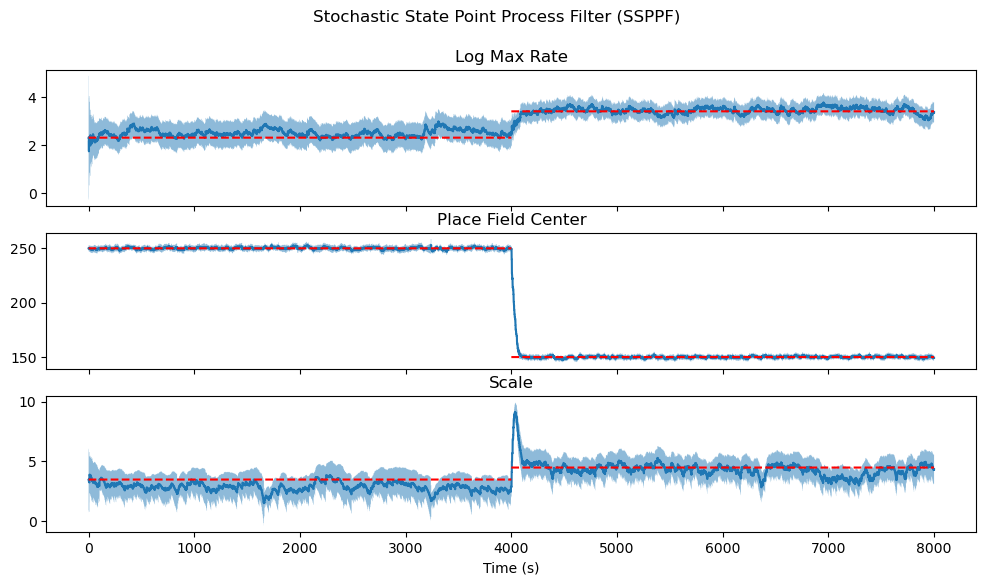

In [3]:
transition_matrix = np.identity(3)
covariance_matrix = np.diag([1e-5, 1e-3, 1e-4])

(
    posterior_mode,
    posterior_covariance,
) = stochastic_point_process_filter(
    init_mean_params=true_params1,
    init_variance_params=np.identity(3),
    x=position,
    spike_indicator=spike_indicator,
    dt=dt,
    transition_matrix=transition_matrix,
    covariance_matrix=covariance_matrix,
    log_receptive_field_model=log_receptive_field_model,
)

ci = get_confidence_interval(posterior_mode=posterior_mode, posterior_covariance=posterior_covariance, alpha=0.01)

plot_jump_results(time, true_params1, true_params2, posterior_mode, ci=ci)
plt.suptitle("Stochastic State Point Process Filter (SSPPF)")

Text(0.5, 0.98, 'Stochastic State Point Process Smoother (SSPPS)')

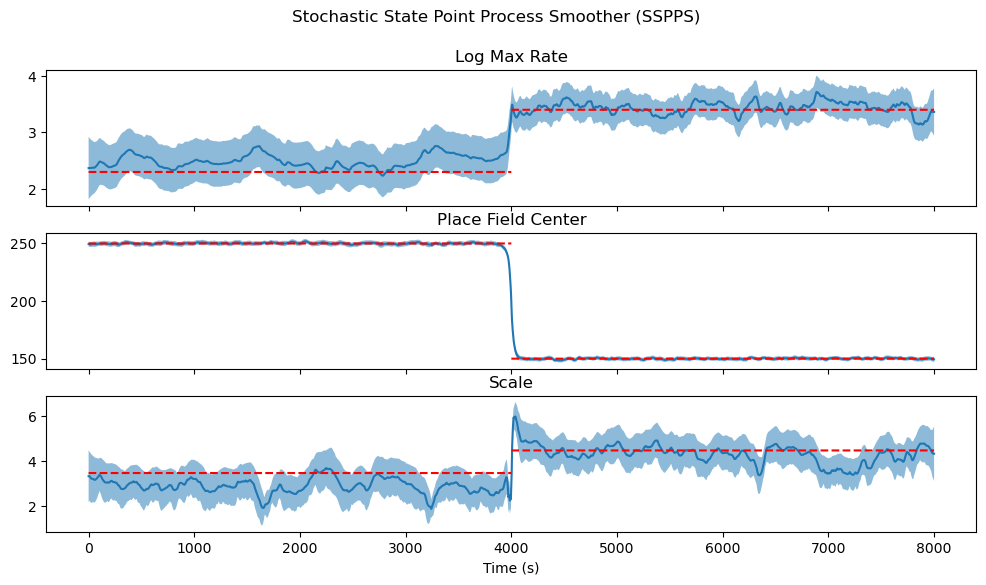

In [4]:
from state_space_practice.switching_kalman import _kalman_smoother_update


def smoother(
    filter_mean,
    filter_cov,
    process_cov,
    transition_matrix,
):
    def _step(carry, args):
        (
            next_smoother_mean,
            next_smoother_cov,
        ) = carry

        filter_mean, filter_cov = args

        smoother_mean, smoother_cov, smoother_cross_cov = _kalman_smoother_update(
            next_smoother_mean,
            next_smoother_cov,
            filter_mean,
            filter_cov,
            process_cov,
            transition_matrix,
        )
        return (
            smoother_mean,
            smoother_cov,
        ), (
            smoother_mean,
            smoother_cov,
            smoother_cross_cov,
        )

    (_, _), (smoother_mean, smoother_cov, smoother_cross_cov) = jax.lax.scan(
        _step,
        (filter_mean[-1], filter_cov[-1]),
        (filter_mean[:-1], filter_cov[:-1]),
        reverse=True,
    )

    smoother_mean = jnp.concatenate((smoother_mean, filter_mean[-1][None]))
    smoother_cov = jnp.concatenate((smoother_cov, filter_cov[-1][None]))

    return smoother_mean, smoother_cov, smoother_cross_cov

smoother_mean, smoother_cov, smoother_cross_cov = smoother(
    posterior_mode,
    posterior_covariance,
    covariance_matrix,
    transition_matrix,
)

ci = get_confidence_interval(
    posterior_mode=smoother_mean, posterior_covariance=smoother_cov, alpha=0.01
)

plot_jump_results(time, true_params1, true_params2, smoother_mean, ci=ci)
plt.suptitle("Stochastic State Point Process Smoother (SSPPS)")

In [ ]:
transition_matrix = np.identity(3)
covariance_matrix = np.diag([1e-5, 1e-3, 1e-4])
init_mean_params = true_params1
init_variance_params = np.identity(3)

for i in range(3):
    (
        posterior_mode,
        posterior_covariance,
    ) = stochastic_point_process_filter(
        init_mean_params=init_mean_params,
        init_variance_params=init_variance_params,
        x=position,
        spike_indicator=spike_indicator,
        dt=dt,
        transition_matrix=transition_matrix,
        covariance_matrix=covariance_matrix,
        log_receptive_field_model=log_receptive_field_model,
    )

    smoother_mean, smoother_cov, smoother_cross_cov = smoother(
        posterior_mode,
        posterior_covariance,
        covariance_matrix,
        transition_matrix,
    )

In [5]:
def steepest_descent_point_process_filter(
    init_mean_params: jnp.ndarray,
    x: jnp.ndarray,
    spike_indicator: jnp.ndarray,
    dt: float,
    epsilon: jnp.ndarray,
    log_receptive_field_model: callable,
) -> jnp.ndarray:
    """Steepest Descent Point Process Filter (SDPPF)

    Parameters
    ----------
    init_mean_params : jnp.ndarray, shape (n_params,)
    x : jnp.ndarray, shape (n_time,)
        linear-valued input signal
    spike_indicator : jnp.ndarray, shape (n_time,)
        Spike count
    dt : float
        Time step
    epsilon : jnp.ndarray, shape (n_params, n_params)
        Learning rate
    log_receptive_field_model : callable
        Function that takes in `x` and parameters and returns the log spike rate

    Returns
    -------
    posterior_mode : jnp.ndarray, shape (n_time, n_params)
    """
    grad_log_receptive_field_model = jax.grad(log_receptive_field_model, argnums=1)

    def _update(
        mode_prev: jnp.ndarray, args: tuple[jnp.ndarray, jnp.ndarray]
    ) -> tuple[jnp.ndarray, jnp.ndarray]:
        """Steepest Descent Point Process Filter update step"""
        x_t, spike_indicator_t = args
        conditional_intensity = jnp.exp(log_receptive_field_model(x_t, mode_prev))
        innovation = spike_indicator_t - conditional_intensity * dt
        one_step_grad = grad_log_receptive_field_model(x_t, mode_prev)
        posterior_mode = mode_prev + epsilon @ one_step_grad * innovation

        return posterior_mode, posterior_mode

    return jax.lax.scan(_update, init_mean_params, (x, spike_indicator))[1]


Text(0.5, 0.98, 'Steepest Descent Point Process Filter (SDPPF)')

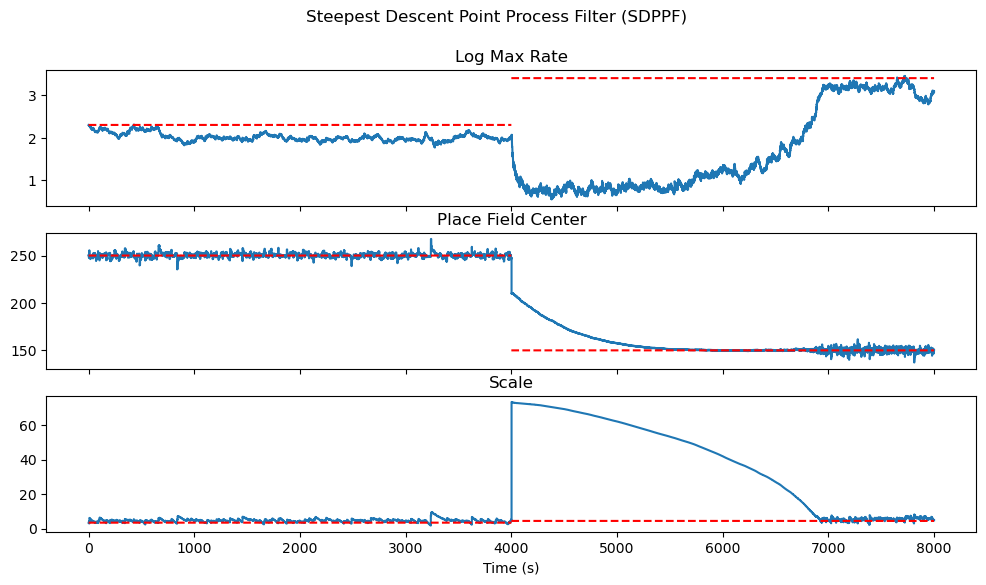

In [6]:
epsilon = np.diag([0.02, 10.0, 1.0])

posterior_mode2 = steepest_descent_point_process_filter(
    true_params1, position, spike_indicator, dt, epsilon, log_receptive_field_model
)

plot_jump_results(time, true_params1, true_params2, posterior_mode2)
plt.suptitle("Steepest Descent Point Process Filter (SDPPF)")

In [7]:
def receptive_field_model(position: np.ndarray, params: np.ndarray) -> np.ndarray:
    if params.ndim == 1:
        params = params[None]
    log_max_rate, place_field_center, scale = params.T
    return np.exp(log_max_rate - (position - place_field_center) ** 2 / (2 * scale**2))


def simulate_eden_brown_2004_linear():
    dt = 0.020  # seconds
    total_time = 8000.0  # seconds
    n_total_steps = int(total_time / dt)

    time = np.arange(0, total_time, dt)

    speed = 125.0  # cm/s
    track_length = 300.0  # cm

    run1 = np.arange(0, track_length, speed * dt)
    run2 = np.arange(track_length, 0, -speed * dt)
    run = np.concatenate((run1, run2))

    position = np.concatenate([run] * int(np.ceil(n_total_steps / run.shape[0])))
    position = position[:n_total_steps]

    true_params1 = np.array([np.log(10.0), 250.0, np.sqrt(12.0)])
    true_params2 = np.array([np.log(30.0), 150.0, np.sqrt(20.0)])

    # Interpolate between true_params1 and true_params2
    true_params = np.linspace(true_params1, true_params2, n_total_steps)
    true_rate = receptive_field_model(position, true_params)
    spike_indicator = np.random.poisson(true_rate * dt)

    return time, position, spike_indicator, dt, true_params


def plot_linear_results(time, true_params, posterior_mode, ci=None):
    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(time, posterior_mode[:, 0])
    axes[0].plot(
        time,
        true_params[:, 0],
        linestyle="--",
        color="red",
    )
    axes[0].set_title("Log Max Rate")
    axes[1].plot(time, posterior_mode[:, 1])
    axes[1].plot(
        time,
        true_params[:, 1],
        linestyle="--",
        color="red",
    )
    axes[1].set_title("Place Field Center")
    axes[2].plot(time, posterior_mode[:, 2])
    axes[2].plot(
        time,
        true_params[:, 2],
        linestyle="--",
        color="red",
    )
    axes[2].set_title("Scale")
    axes[-1].set_xlabel("Time (s)")

    if ci is not None:
        for i, ax in enumerate(axes):
            ax.fill_between(time, ci[:, i, 0], ci[:, i, 1], alpha=0.5)

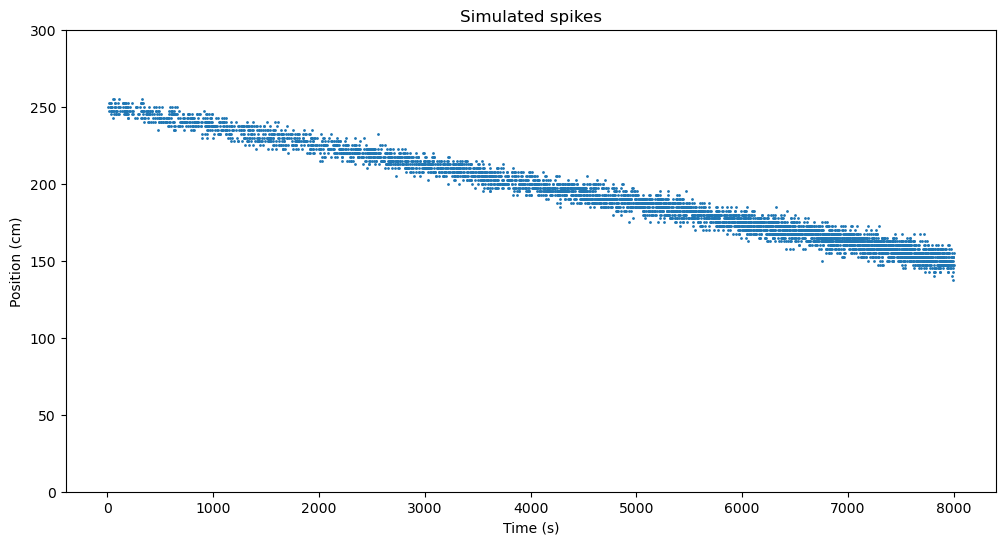

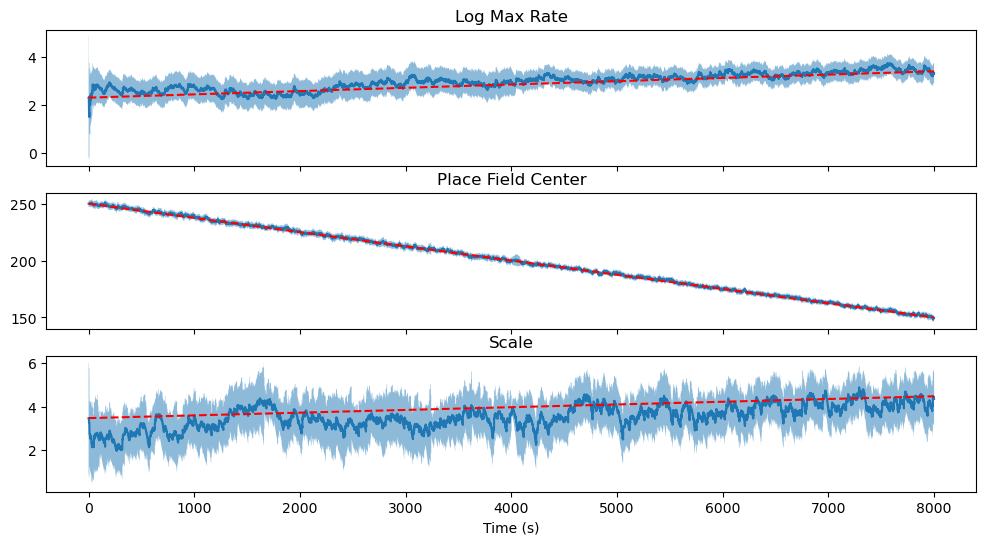

In [8]:
time, position, spike_indicator, dt, true_params = simulate_eden_brown_2004_linear()
plt.figure(figsize=(12, 6))
plt.scatter(
    time[spike_indicator.nonzero()[0]], position[spike_indicator.nonzero()[0]], s=1
)
plt.ylim((0, 300))
plt.ylabel("Position (cm)")
plt.xlabel("Time (s)")
plt.title("Simulated spikes")

transition_matrix = np.identity(3)
covariance_matrix = np.diag([1e-5, 1e-3, 1e-4])

(
    posterior_mode,
    posterior_variance,
) = stochastic_point_process_filter(
    init_mean_params=true_params1,
    init_variance_params=np.identity(3),
    x=position,
    spike_indicator=spike_indicator,
    dt=dt,
    transition_matrix=transition_matrix,
    covariance_matrix=covariance_matrix,
    log_receptive_field_model=log_receptive_field_model,
)
ci = get_confidence_interval(
    posterior_mode=posterior_mode, posterior_covariance=posterior_covariance, alpha=0.01
)
plot_linear_results(time, true_params, posterior_mode, ci=ci)

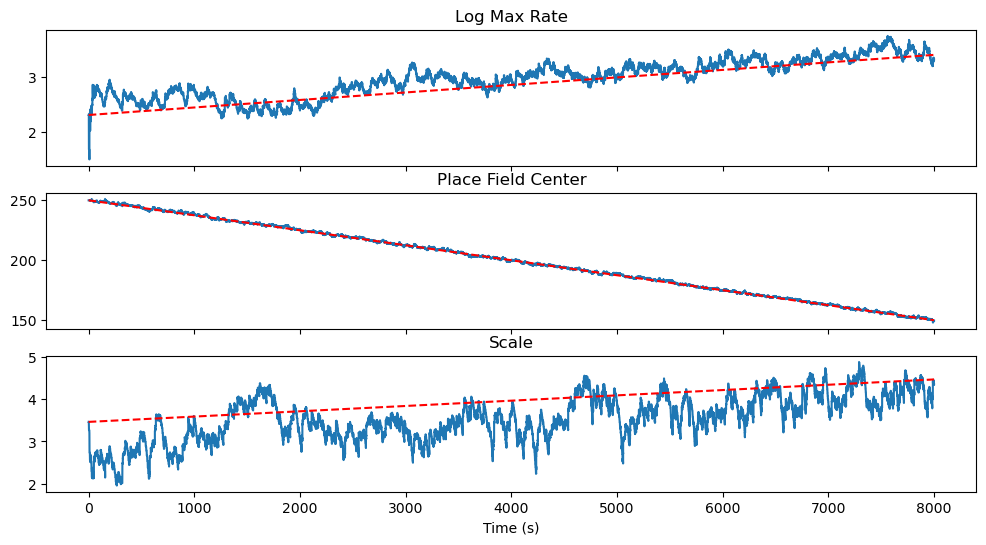

In [9]:
epsilon = np.diag([0.02, 10.0, 1.0])

posterior_mode2 = steepest_descent_point_process_filter(
    true_params1, position, spike_indicator, dt, epsilon, log_receptive_field_model
)
plot_linear_results(time, true_params, posterior_mode)